In [7]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import seaborn as sns
import pandas as pd
_here = Path.cwd().resolve()
_root = next(p for p in [_here, *_here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(_root / "src"))
from regression_modelling.models.cv import (
    full_coverage_cities, load_pooled_table, loco_folds,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# Load 5 cities with crime comprehensive crime incident coverage 
cities = full_coverage_cities()            # ['houston','chicago','atlanta','kansas_city','detroit']
pooled = load_pooled_table()      # concat + city col + drop zero/NaN-pop, prints fold sizes

# inspect the LOCO split
for city, train, holdout in loco_folds(pooled):
    print(city, "→ train", train.shape, "holdout", holdout.shape)

  houston            1629 BGs
  chicago            2164 BGs
  atlanta             426 BGs
  kansas_city         473 BGs
  detroit             622 BGs
  pooled             5314 BGs across 5 cities
  dropped 22 zero/NaN-pop BGs -> 5292 remain (filtered geoid set for fit + Moran's I + bias join)
atlanta → train (4868, 70) holdout (424, 70)
chicago → train (3131, 70) holdout (2161, 70)
detroit → train (4682, 70) holdout (610, 70)
houston → train (3664, 70) holdout (1628, 70)
kansas_city → train (4823, 70) holdout (469, 70)


### Component 2 — leakage-safe fit / predict core

One design matrix, three target forms. The predictor scaler is fit on the **train cities
only** and applied to the holdout, so no holdout information touches the fit.

- `rate_within_city` — **headline (c)**: per-city z-scored rate (relative within-city risk)
- `rate` — **reported (a)**: raw rate (absolute level)
- `logcount` — comparator: log(count+1)

Demonstrated below on a **single fold** (hold out one city). The full LOCO loop is the next
component.

In [9]:
from scipy.stats import spearmanr
from regression_modelling.models.cv import (
    fit_fold, predict_fold, make_target, TARGET_MODES,
)

# one fold: hold out a chosen city, train on the other four
HOLDOUT = "chicago"
folds = {c: (tr, ho) for c, tr, ho in loco_folds(pooled)}
train, holdout = folds[HOLDOUT]
print(f"holdout={HOLDOUT}  train={train.shape}  holdout={holdout.shape}")

holdout=chicago  train=(3131, 70)  holdout=(2161, 70)


In [10]:
# fit each target mode on the train fold, score the held-out city
rows = []
scored_by_mode = {}
for mode in TARGET_MODES:
    fit = fit_fold(train, mode=mode)
    scored = predict_fold(fit, holdout)
    scored_by_mode[mode] = scored
    rows.append({
        "mode": mode,
        "n_train": fit["n_train"],
        "adj_r2_in_sample": round(fit["result"].rsquared_adj, 3),
        "holdout_n": len(scored),
        # ranking sanity: predicted risk vs ACTUAL holdout rate (headline metric is rank-based)
        "spearman_pred_vs_rate": round(spearmanr(scored["y_pred"], scored["cl_total_rate"]).statistic, 3),
    })
pd.DataFrame(rows).set_index("mode")

,n_train,adj_r2_in_sample,holdout_n,spearman_pred_vs_rate
mode,,,,
rate_within_city,2956,0.057,2064,0.318
rate,2956,0.022,2064,0.257
logcount,2956,0.375,2064,0.530


In [11]:
# peek at the headline (within-city) fold's top predicted-risk BGs in the held-out city
scored_by_mode["rate_within_city"][["geoid", "city", "population", "cl_total_count",
                                      "cl_total_rate", "y_pred"]] \
    .sort_values("y_pred", ascending=False).head(10)

,geoid,city,population,cl_total_count,cl_total_rate,y_pred
3689,170318391001,chicago,4975.0,1581.0,317.788945,1.542109
2972,170315001004,chicago,1458.0,65.0,44.581619,1.103407
3791,170319801001,chicago,18.0,130.0,7222.222222,1.085426
3027,170315401012,chicago,2464.0,119.0,48.295455,0.947197
3762,170318428004,chicago,1106.0,63.0,56.962025,0.911544
3129,170316113002,chicago,1064.0,15.0,14.097744,0.877478
2983,170315103002,chicago,1050.0,150.0,142.857143,0.869075
2887,170314602001,chicago,779.0,39.0,50.064185,0.858509
3597,170318340001,chicago,2777.0,73.0,26.287360,0.827448
3614,170318346002,chicago,1151.0,124.0,107.732407,0.811555


### Component 3 — LOCO driver (all 5 folds)

Rotating leave-one-city-out for each target mode: fit on the four train cities, score the
held-out city, repeat. `run_all_modes` returns `{mode: result}` where each result carries
`scored` (every BG's **out-of-sample** prediction) and per-fold `fits`.

In [12]:
from regression_modelling.models.cv import run_loco, run_all_modes, loco_metrics, plot_lorenz

runs = run_all_modes(pooled)   # rate_within_city (headline), rate (reported), logcount (comparator)

LOCO — target mode = 'rate_within_city' (cl_total)
  holdout=atlanta        n_train= 4651 scored=  369 adjR2_in= 0.037
  holdout=chicago        n_train= 2956 scored= 2064 adjR2_in= 0.057
  holdout=detroit        n_train= 4415 scored=  605 adjR2_in= 0.037
  holdout=houston        n_train= 3483 scored= 1537 adjR2_in= 0.065
  holdout=kansas_city    n_train= 4575 scored=  445 adjR2_in= 0.041
  -> 5020 BGs scored out-of-sample across 5 folds
LOCO — target mode = 'rate' (cl_total)
  holdout=atlanta        n_train= 4651 scored=  369 adjR2_in= 0.012
  holdout=chicago        n_train= 2956 scored= 2064 adjR2_in= 0.022
  holdout=detroit        n_train= 4415 scored=  605 adjR2_in= 0.011
  holdout=houston        n_train= 3483 scored= 1537 adjR2_in= 0.065
  holdout=kansas_city    n_train= 4575 scored=  445 adjR2_in= 0.011
  -> 5020 BGs scored out-of-sample across 5 folds
LOCO — target mode = 'logcount' (cl_total)
  holdout=atlanta        n_train= 4651 scored=  369 adjR2_in= 0.400
  holdout=chicago  

### Component 4 — held-out metrics

**Headline = concentration/Lorenz.** `gini` = model concentration (0 = no skill), `gini_oracle`
= best achievable, `skill` = gini/gini_oracle, `capture@20` = share of crime in the highest-risk
BGs covering 20% of population. `spearman` = rank corr of predicted score vs actual rate.
R²/RMSE/MAE appear only for the absolute `rate` mode.

In [13]:
# headline target: within-city standardized rate, population-weighted x-axis
loco_metrics(runs["rate_within_city"], x_unit="population")

,n,gini,gini_oracle,skill,capture@20,spearman
holdout,,,,,,
atlanta,369,0.070,0.463,0.150,0.240,0.107
chicago,2064,0.114,0.445,0.257,0.266,0.318
detroit,605,0.129,0.293,0.439,0.272,0.379
houston,1537,0.166,0.520,0.319,0.284,0.254
kansas_city,445,0.239,0.517,0.462,0.364,0.406
POOLED,5020,0.139,0.470,0.296,0.274,0.299


In [14]:
# reported target (a): plain pooled raw rate — adds out-of-sample R2/RMSE/MAE
loco_metrics(runs["rate"], x_unit="population")

,n,gini,gini_oracle,skill,capture@20,spearman,r2_oos,rmse,mae
holdout,,,,,,,,,
atlanta,369,-0.071,0.463,-0.153,0.212,-0.223,-120.862,524.04,417.28
chicago,2064,0.062,0.445,0.139,0.243,0.257,-8.846,555.77,433.03
detroit,605,0.020,0.293,0.069,0.228,0.023,-0.254,419.88,237.27
houston,1537,0.074,0.520,0.142,0.217,0.117,0.004,3240.29,161.42
kansas_city,445,0.111,0.517,0.215,0.258,0.210,-0.059,431.46,210.68
POOLED,5020,0.051,0.470,0.108,0.220,0.128,-0.038,1843.80,305.41


In [15]:
# comparator: log(count+1)
loco_metrics(runs["logcount"], x_unit="population")

,n,gini,gini_oracle,skill,capture@20,spearman
holdout,,,,,,
atlanta,369,0.283,0.463,0.611,0.357,0.652
chicago,2064,0.275,0.445,0.619,0.371,0.530
detroit,605,0.161,0.293,0.551,0.292,0.434
houston,1537,0.329,0.520,0.634,0.389,0.599
kansas_city,445,0.387,0.517,0.749,0.448,0.707
POOLED,5020,0.285,0.470,0.605,0.366,0.560


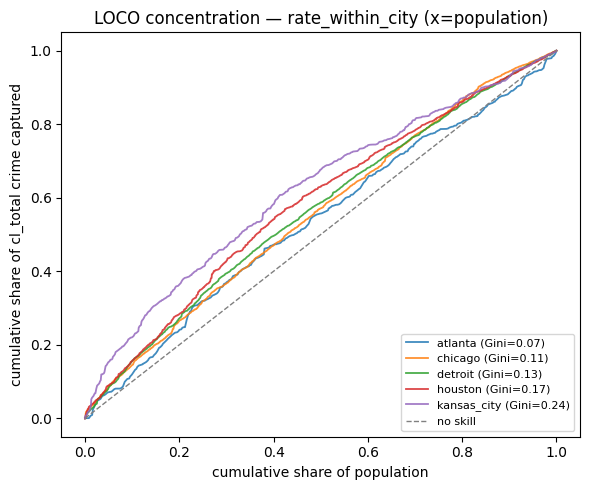

<Axes: title={'center': 'LOCO concentration — rate_within_city (x=population)'}, xlabel='cumulative share of population', ylabel='cumulative share of cl_total crime captured'>

In [16]:
# concentration curves per held-out city (headline target)
plot_lorenz(runs["rate_within_city"], x_unit="population")

#### x-axis sensitivity — population vs block-group

Population-weighting is the default (per-capita rate index). The BG-axis is the per-place
framing; compare to see how much the ranking verdict depends on the weighting choice.

In [17]:
loco_metrics(runs["rate_within_city"], x_unit="bg")

,n,gini,gini_oracle,skill,capture@20,spearman
holdout,,,,,,
atlanta,369,0.114,0.458,0.249,0.292,0.107
chicago,2064,0.108,0.464,0.233,0.260,0.318
detroit,605,0.061,0.324,0.188,0.215,0.379
houston,1537,0.183,0.521,0.352,0.291,0.254
kansas_city,445,0.224,0.461,0.485,0.335,0.406
POOLED,5020,0.134,0.477,0.280,0.268,0.299
